In [ ]:
from google.colab import files
import zipfile
import os

# Upload the zip containing the 'src' directory
print("Please upload src.zip (containing the training and evaluation folders)")
zip_upload = files.upload()

for fn in zip_upload.keys():
  with zipfile.ZipFile(fn, 'r') as zip_ref:
      zip_ref.extractall('.')
  print(f"Extracted {fn} to current directory.")

Please upload src.zip (containing the training and evaluation folders)


Saving src.zip to src.zip
Extracted src.zip to current directory.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving delhi_aqi_features.csv to delhi_aqi_features.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import io

In [ ]:
df = pd.read_csv(io.BytesIO(uploaded['delhi_aqi_features.csv']))
df.head()

,datetime,location_lat,location_lon,co,no2,o3,pm10,pm25,so2,aqi,...,wind_from_nw,wind_from_se,diwali_window,stubble_season,winter_flag,rush_hour,night_flag,winter_night_stagnation,stubble_nw_wind,pm25_pm10_ratio
0,2019-01-08 00:00:00,28.5355,77.3178,0.458700,19.591786,36.655121,72.092144,53.864918,4.835449,192.401344,...,1,0,0,0,1,0,1,10.875000,0,0.747168
1,2019-01-08 01:00:00,28.5355,77.3178,0.776717,21.570298,38.989381,76.169286,58.724265,6.258830,204.464234,...,1,0,0,0,1,0,1,11.125000,0,0.770970
2,2019-01-08 02:00:00,28.5355,77.3178,0.684288,30.274686,39.785910,107.791009,67.325879,5.274812,213.428021,...,1,0,0,0,1,0,1,11.375000,0,0.624596
3,2019-01-08 03:00:00,28.5355,77.3178,0.492499,29.543944,51.266713,101.423825,74.447837,6.279582,220.849851,...,1,0,0,0,1,0,1,10.340909,0,0.734027
4,2019-01-08 04:00:00,28.5355,77.3178,0.757127,33.627284,61.958740,92.517704,60.432670,2.786102,206.244572,...,1,0,0,0,1,0,1,11.219512,0,0.653201


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43657 entries, 0 to 43656
Columns: 135 entries, datetime to pm25_pm10_ratio
dtypes: float64(119), int64(15), object(1)
memory usage: 45.0+ MB


In [ ]:
df.describe()

,location_lat,location_lon,co,no2,o3,pm10,pm25,so2,aqi,hour,...,wind_from_nw,wind_from_se,diwali_window,stubble_season,winter_flag,rush_hour,night_flag,winter_night_stagnation,stubble_nw_wind,pm25_pm10_ratio
count,4.365700e+04,4.365700e+04,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,...,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000,43657.000000
mean,2.853550e+01,7.731780e+01,0.548612,21.951887,32.827850,82.124492,54.795276,5.477487,164.431706,11.499737,...,0.522345,0.285934,0.011109,0.129189,0.326568,0.374991,0.333349,1.188305,0.085004,0.685697
std,1.787035e-12,3.998980e-11,0.260585,12.423393,16.514458,39.515693,26.024321,2.602566,67.898415,6.922405,...,0.499506,0.451863,0.104815,0.335413,0.468963,0.484126,0.471415,4.119395,0.278890,0.176012
min,2.853550e+01,7.731780e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.853550e+01,7.731780e+01,0.333017,11.061815,18.377080,49.780485,33.126872,3.319800,95.240031,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.620853
50%,2.853550e+01,7.731780e+01,0.549160,21.882461,32.742627,81.856167,54.791426,5.468293,196.987558,11.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.667051
75%,2.853550e+01,7.731780e+01,0.765673,32.828318,47.323483,114.509481,76.278793,7.638603,222.757900,17.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.718089
max,2.853550e+01,7.731780e+01,1.293519,55.187949,79.513391,185.521590,125.195447,13.028780,273.734202,23.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,138.000000,1.000000,2.000000


In [ ]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

In [ ]:
target = "pm25"

print(f"Shape: {df.shape}")
print(f"Target: {target}")
print(f"Date range: {df.index.min()} → {df.index.max()}")


Shape: (43657, 135)
Target: pm25
Date range: 0 → 43656


In [ ]:
import sys
import os
from pathlib import Path

In [ ]:
# Temporal Train/Val/Test Split
from src.training.split import temporal_split

train, val, test = temporal_split(df, val_frac=0.15, test_frac=0.15)
print(f"Train shape: {train.shape}")
print(f"Val shape: {val.shape}")
print(f"Test shape: {test.shape}")

Temporal Split:
  Train: 0 → 30558 (30,559 rows, 70%)
  Val:   30559 → 37107 (6,549 rows, 15%)
  Test:  37108 → 43656 (6,549 rows, 15%)
Train shape: (30559, 135)
Val shape: (6549, 135)
Test shape: (6549, 135)


#Naive Baselines

In [ ]:
# Run Naive Models
from src.evaluation.metrics import calculate_metrics, print_comparison_table

all_results = {}

# Naive Persistence
# Forecast = previous hour's value
naive_pred = test[target].shift(1).dropna()
naive_actual = test[target].iloc[1:]

metrics = calculate_metrics(naive_actual.values, naive_pred.values)
all_results["Naive Persistence"] = metrics
print(f"Naive Persistence: {metrics}")

# Store naive MAE for MASE computation
naive_mae = metrics["MAE"]

# Seasonal Naive (24h)
# Forecast = same hour yesterday
seasonal_pred = test[target].shift(24).dropna()
seasonal_actual = test[target].iloc[24:]

metrics = calculate_metrics(seasonal_actual.values, seasonal_pred.values)
all_results["Seasonal Naive (24h)"] = metrics
print(f"Seasonal Naive (24h): {metrics}")

# Moving Average (24h)
ma24_pred = test[target].rolling(window=24, min_periods=1).mean().shift(1).dropna()
ma24_actual = test[target].iloc[1:]

metrics = calculate_metrics(ma24_actual.values, ma24_pred.values)
all_results["Moving Avg (24h)"] = metrics
print(f"Moving Avg (24h): {metrics}")

# Moving Average (48h)
ma48_pred = test[target].rolling(window=48, min_periods=1).mean().shift(1).dropna()
ma48_actual = test[target].iloc[1:]

# Align lengths
min_len = min(len(ma48_actual), len(ma48_pred))
metrics = calculate_metrics(ma48_actual.values[:min_len], ma48_pred.values[:min_len])
all_results["Moving Avg (48h)"] = metrics
print(f"Moving Avg (48h): {metrics}")

Naive Persistence: {'MAE': 9.98, 'RMSE': np.float64(12.56), 'MAPE': np.float64(35.22), 'MASE': 1.0}
Seasonal Naive (24h): {'MAE': 9.98, 'RMSE': np.float64(12.5), 'MAPE': np.float64(35.69), 'MASE': 1.0005}
Moving Avg (24h): {'MAE': 9.58, 'RMSE': np.float64(11.85), 'MAPE': np.float64(38.08), 'MASE': 0.9599}
Moving Avg (48h): {'MAE': 9.53, 'RMSE': np.float64(11.78), 'MAPE': np.float64(37.95), 'MASE': 0.9544}


#Linear Regression Baseline

In [ ]:
# Ridge Regression - Stricter leakage prevention
from src.models.baselines import LinearBaseline

# Get feature columns
feature_cols = [c for c in train.columns if c != target]

# Remove all target-derived features that aren't strictly simple lags
# We remove rolling stats, ratios, and especially DIFFs which often cause leakage
leakage_keywords = ['rmean', 'rstd', 'rmin', 'rmax', 'rrange', 'pct', 'accel', 'ratio', 'diff', 'aqi', 'pm10']
leakage_cols = [c for c in feature_cols if any(k in c for k in leakage_keywords) and c != target]

if leakage_cols:
    print(f"Removing {len(leakage_cols)} potential leakage columns including diffs and other pollutants.")
    feature_cols = [c for c in feature_cols if c not in leakage_cols]

# Keep only numeric features
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train[c])]
feature_cols = numeric_cols
print(f"Using {len(feature_cols)} numeric features (mostly lags and temporal features)")

# Handle NaN/inf
train_clean = train[feature_cols + [target]].replace([np.inf, -np.inf], np.nan).dropna()
test_clean = test[feature_cols + [target]].replace([np.inf, -np.inf], np.nan).dropna()

linear = LinearBaseline(alpha=1.0)
linear.fit(train_clean, target=target)

# Predict on test
linear_pred = linear.predict_all(test_clean)
linear_actual = test_clean[target].values

metrics = calculate_metrics(linear_actual, linear_pred)
all_results["Linear (Ridge)"] = metrics
print(f"Linear (Ridge): {metrics}")

# Top features
print("\nTop 15 features by coefficient magnitude:")
top_feats = linear.get_top_features(15)
for feat, importance in top_feats.items():
    print(f"  {feat:30s} {importance:.4f}")

Removing 45 potential leakage columns including diffs and other pollutants.
Using 88 numeric features (mostly lags and temporal features)
Linear (Ridge): {'MAE': 7.01, 'RMSE': np.float64(8.82), 'MAPE': np.float64(26.43), 'MASE': 0.7023}

Top 15 features by coefficient magnitude:
  doy_sin                        32.9215
  hour_sin                       10.7776
  diwali_window                  0.8552
  co_lag_6                       0.6422
  co                             0.4270
  doy_cos                        0.4171
  night_flag                     0.4072
  month_cos                      0.3779
  hour_cos2                      0.3201
  co_lag_24                      0.2927
  stubble_nw_wind                0.2478
  wind_from_se                   0.2149
  rush_hour                      0.2148
  fog_risk                       0.2061
  hour_sin2                      0.1762


#SARIMA Baseline

In [ ]:
# Fit SARIMA on Daily Data
from src.models.baselines import SARIMABaseline

sarima = SARIMABaseline(order=(2, 1, 2), seasonal_order=(1, 1, 1, 7))

try:
    sarima.fit(train, target=target)

    # Predict on test period (daily)
    test_daily = test[target].resample("1D").mean().dropna()
    pred_mean, pred_ci = sarima.predict_all_daily(test_daily.index)

    sarima_metrics = calculate_metrics(test_daily.values, pred_mean.values)
    all_results["SARIMA (daily)"] = sarima_metrics
    print(f"SARIMA (daily): {sarima_metrics}")

    # Plot SARIMA forecast
    fig, ax = plt.subplots(figsize=(14, 5))

    # Last 30 days of training + full test
    train_daily = train[target].resample("1D").mean().dropna()
    ax.plot(train_daily.index[-30:], train_daily.values[-30:],
            color="#2563EB", linewidth=1.5, label="Train (last 30d)")
    ax.plot(test_daily.index, test_daily.values,
            color="#000000", linewidth=1.5, label="Actual")
    ax.plot(pred_mean.index, pred_mean.values,
            color="#DC2626", linewidth=1.5, linestyle="--", label="SARIMA Forecast")

    # Confidence intervals
    ax.fill_between(pred_ci.index,
                     pred_ci.iloc[:, 0],
                     pred_ci.iloc[:, 1],
                     alpha=0.15, color="#DC2626", label="95% CI")

    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_title("SARIMA Daily Forecast vs Actual")
    ax.legend()
    plt.tight_layout()
    plt.show()

    sarima_fitted = True

except Exception as e:
    print(f"SARIMA failed: {e}")
    print("This is OK — SARIMA on long series can be slow/unstable.")
    print("The other baselines are sufficient.")
    sarima_fitted = False

SARIMA failed: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'
This is OK — SARIMA on long series can be slow/unstable.
The other baselines are sufficient.


#Comparison

In [ ]:
# Update Results Table with fixed Linear model
results_df = print_comparison_table(all_results)


MODEL COMPARISON
                       MAE   RMSE   MAPE    MASE
Model                                           
Naive Persistence     9.98  12.56  35.22  1.0000
Seasonal Naive (24h)  9.98  12.50  35.69  1.0005
Moving Avg (24h)      9.58  11.85  38.08  0.9599
Moving Avg (48h)      9.53  11.78  37.95  0.9544
Linear (Ridge)        7.01   8.82  26.43  0.7023
-----------------------------------------------------------------

  Best model (by MAE): Linear (Ridge)
  MAE improvement over naive: 29.8%


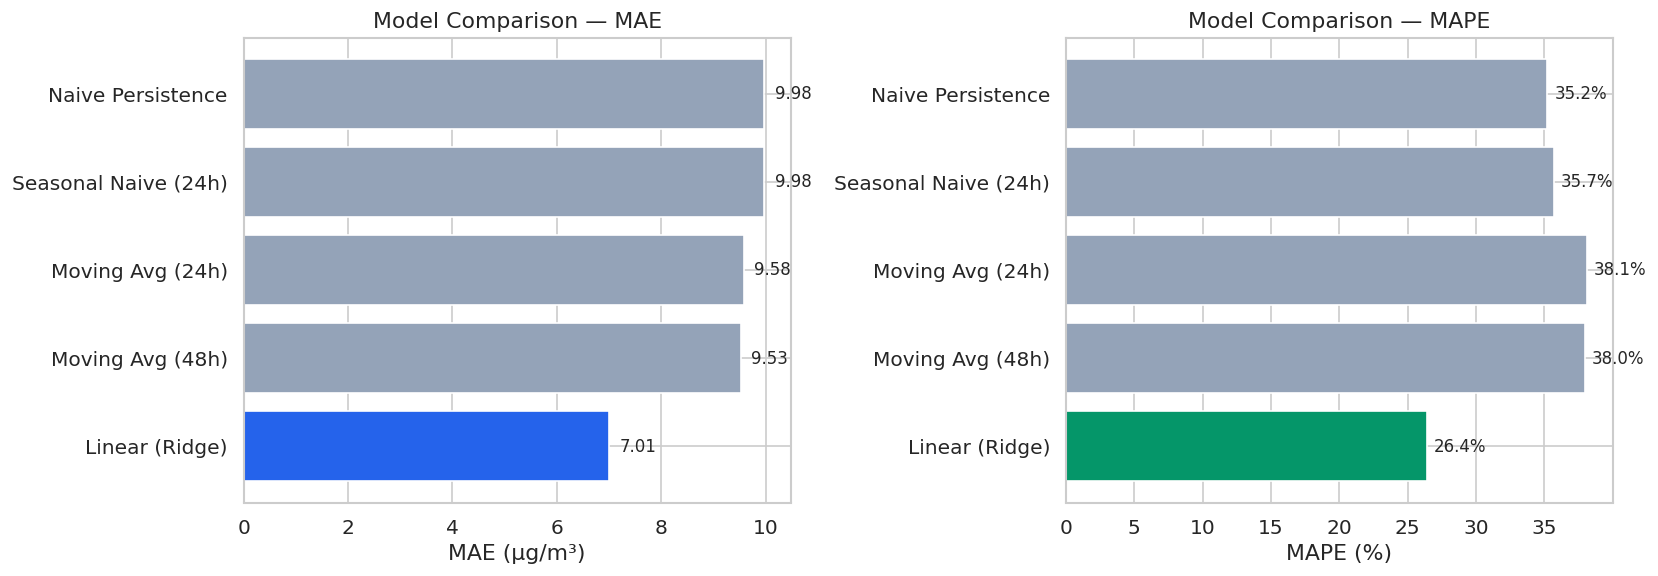

In [ ]:
# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = list(all_results.keys())
maes = [all_results[m]["MAE"] for m in models]
colors = ["#94A3B8"] * len(models)
best_idx = np.argmin(maes)
colors[best_idx] = "#2563EB"

axes[0].barh(range(len(models)), maes, color=colors)
axes[0].set_yticks(range(len(models)))
axes[0].set_yticklabels(models)
axes[0].set_xlabel("MAE (µg/m³)")
axes[0].set_title("Model Comparison — MAE")
axes[0].invert_yaxis()

for i, v in enumerate(maes):
    axes[0].text(v + 0.2, i, f"{v:.2f}", va="center", fontsize=10)

mapes = [all_results[m]["MAPE"] for m in models]
colors = ["#94A3B8"] * len(models)
best_idx = np.argmin(mapes)
colors[best_idx] = "#059669"

axes[1].barh(range(len(models)), mapes, color=colors)
axes[1].set_yticks(range(len(models)))
axes[1].set_yticklabels(models)
axes[1].set_xlabel("MAPE (%)")
axes[1].set_title("Model Comparison — MAPE")
axes[1].invert_yaxis()

for i, v in enumerate(mapes):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

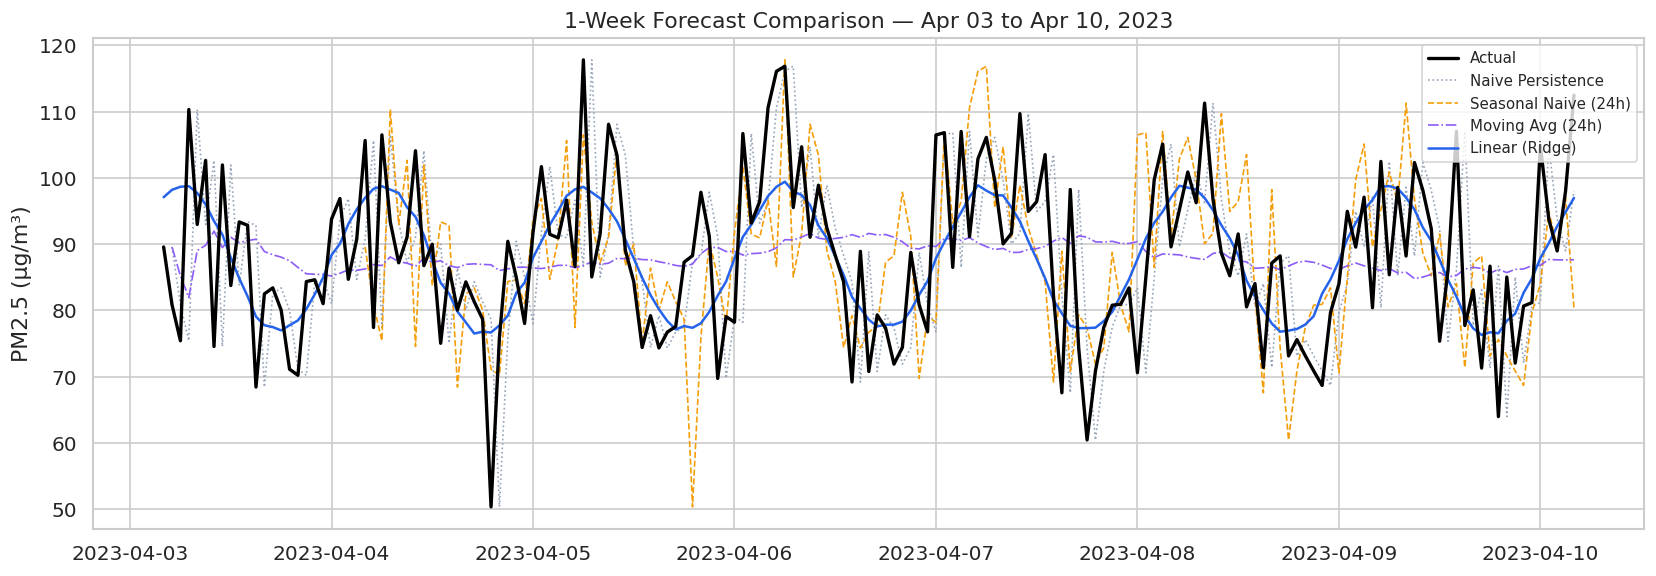

In [ ]:
# Forecast Plots (Test Period Sample)
# Convert index to datetime if it isn't already
if not isinstance(test.index, pd.DatetimeIndex):
    test_plot = test.copy()
    test_plot['datetime'] = pd.to_datetime(test_plot['datetime'])
    test_plot = test_plot.set_index('datetime')
else:
    test_plot = test

# Show a 1-week window from the test set
sample_start = test_plot.index[0]
sample_end = sample_start + pd.Timedelta(days=7)
sample = test_plot.loc[sample_start:sample_end]

fig, ax = plt.subplots(figsize=(14, 5))

# Actual
ax.plot(sample.index, sample[target], color="#000000",
        linewidth=2, label="Actual", zorder=5)

# Naive
ax.plot(sample.index, sample[target].shift(1),
        color="#94A3B8", linewidth=1, linestyle=":", label="Naive Persistence")

# Seasonal Naive
ax.plot(sample.index, sample[target].shift(24),
        color="#F59E0B", linewidth=1, linestyle="--", label="Seasonal Naive (24h)")

# Moving Average
ax.plot(sample.index, sample[target].rolling(24, min_periods=1).mean().shift(1),
        color="#8B5CF6", linewidth=1, linestyle="-.", label="Moving Avg (24h)")

# Linear Ridge (if features available)
if 'feature_cols' in globals() and len(feature_cols) > 0:
    sample_clean = sample[feature_cols + [target]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(sample_clean) > 0:
        linear_sample_pred = linear.predict_all(sample_clean)
        ax.plot(sample_clean.index, linear_sample_pred,
                color="#2563EB", linewidth=1.5, label="Linear (Ridge)")

ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title(f"1-Week Forecast Comparison — {sample_start.strftime('%b %d')} to "
             f"{sample_end.strftime('%b %d, %Y')}")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

#Error Analysis by Season


Linear Model: Error by Season:
         mean  median   std  count
season                            
Autumn   6.92    5.87  5.18    744
Monsoon  7.03    5.84  5.27   2208
Spring   7.35    6.09  5.41    668
Summer   6.94    5.72  5.47   1464
Winter   6.94    5.66  5.44   1465


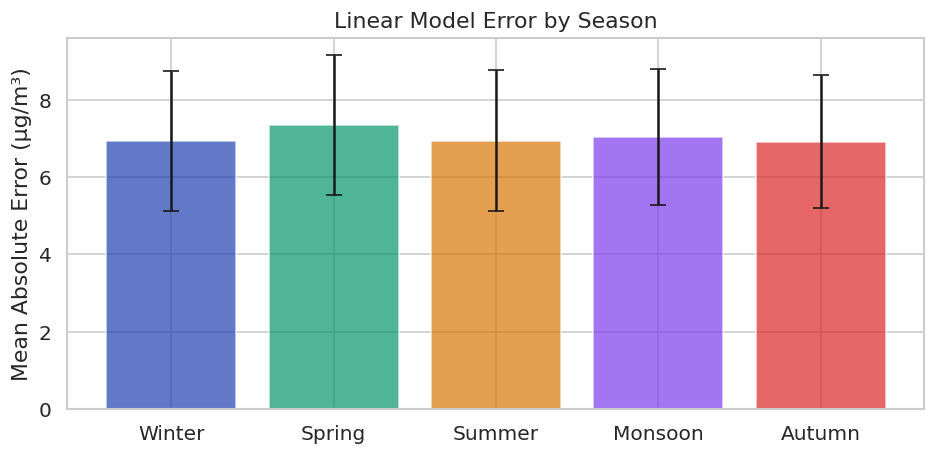

In [ ]:
# Seasonal Error Breakdown
test_with_month = test.copy()

# Ensure we have a datetime index to extract months
if not isinstance(test_with_month.index, pd.DatetimeIndex):
    test_with_month['datetime'] = pd.to_datetime(test_with_month['datetime'])
    test_with_month = test_with_month.set_index('datetime')

test_with_month["month"] = test_with_month.index.month

# Linear model errors
if 'feature_cols' in globals() and len(feature_cols) > 0:
    test_preds = test_clean.copy()

    # Also ensure test_preds has datetime index for seasonal grouping
    if not isinstance(test_preds.index, pd.DatetimeIndex):
        test_preds['datetime'] = pd.to_datetime(test['datetime'])
        test_preds = test_preds.set_index('datetime')

    test_preds["linear_pred"] = linear.predict_all(test_preds[feature_cols])
    test_preds["linear_error"] = (test_preds[target] - test_preds["linear_pred"]).abs()
    test_preds["month"] = test_preds.index.month

    season_map = {
        1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring",
        5: "Summer", 6: "Summer", 7: "Monsoon", 8: "Monsoon",
        9: "Monsoon", 10: "Autumn", 11: "Winter", 12: "Winter"
    }
    test_preds["season"] = test_preds["month"].map(season_map)

    season_errors = test_preds.groupby("season")["linear_error"].agg(
        ["mean", "median", "std", "count"]
    ).round(2)

    print("\nLinear Model: Error by Season:")
    print(season_errors.to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    season_order = ["Winter", "Spring", "Summer", "Monsoon", "Autumn"]
    season_errors = season_errors.reindex(
        [s for s in season_order if s in season_errors.index]
    )

    ax.bar(season_errors.index, season_errors["mean"],
           color=["#1E40AF", "#059669", "#D97706", "#7C3AED", "#DC2626"],
           alpha=0.7, yerr=season_errors["std"] / 3, capsize=5)
    ax.set_ylabel("Mean Absolute Error (µg/m³)")
    ax.set_title("Linear Model Error by Season")
    plt.tight_layout()
    plt.show()

#Results

In [ ]:
# Save Baseline Results

print("""
╔══════════════════════════════════════════════════════════╗
║              PHASE 4 COMPLETE — BASELINES                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Baseline numbers are now established.                   ║
║  Deep learning models must beat these to justify         ║
║  their added complexity.                                 ║
║                                                          ║
║  Key benchmarks to beat:                                 ║
║    MAE:  {best_mae:<8.1f} ({best_model})
║    MAPE: {best_mape:<8.1f}% ({best_mape_model})
║                                                          ║
║  Next: Phase 5 — LSTM from Scratch in PyTorch            ║
║                                                          ║
╕══════════════════════════════════════════════════════════╘
""".format(
    best_mae=results_df["MAE"].min(),
    best_model=results_df["MAE"].idxmin(),
    best_mape=results_df["MAPE"].min(),
    best_mape_model=results_df["MAPE"].idxmin(),
))


╔══════════════════════════════════════════════════════════╗
║              PHASE 4 COMPLETE — BASELINES                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Baseline numbers are now established.                   ║
║  Deep learning models must beat these to justify         ║
║  their added complexity.                                 ║
║                                                          ║
║  Key benchmarks to beat:                                 ║
║    MAE:  7.0      (Linear (Ridge))
║    MAPE: 26.4    % (Linear (Ridge))
║                                                          ║
║  Next: Phase 5 — LSTM from Scratch in PyTorch            ║
║                                                          ║
╕══════════════════════════════════════════════════════════╘

